# AIMD Reuse-Window Caching vs TTL Baselines

This notebook demonstrates a simulated **LLM-agent tool-call loop** over a versioned, volatility-labeled resource corpus, replayed through several per-call-site cache policies:

- **FixedTTLPolicy** — a hand-set fixed TTL per call site (standard-practice baseline).
- **DTTLPolicy** — the literal Basu et al. 2017 (arXiv:1704.04448) Robbins-Monro stochastic-approximation TTL update toward a target hit rate.
- **EWMAAdaptivePolicy** — a correctly-signed fixed-step EWMA-toward-target-hit-rate fallback baseline (added because the literal d-TTL update was found to get trapped at its TTL floor from a low initial TTL).
- **FreshCacheGatePolicy** / **FreshCachePooledPolicy** — a per-site MLE-fitted exponential staleness gate `P(stale|age) = 1 - exp(-lambda*age)`, with a partial-pooling variant for fairness across low-repeat sites.
- **AIMDPolicy (proposed)** — an additive-increase/multiplicative-decrease reuse window driven by confirmed spot-check outcomes rather than any statistical fit.

All policies are replayed through identical synthetic episode traces (Zipf-skewed working-set revisits over a small per-episode set of resources, with `static`/`periodic`/`bursty` version-change schedules) across three volatility regimes (low/medium/high). The notebook re-runs a small-scale version of this simulation directly (it is pure Python/NumPy — no LLM calls, no external dataset dependency, cost = $0) and compares it against a curated summary of the full-scale run (60 resources, 40 episodes/regime, 150 calls/episode) loaded from `mini_demo_data.json`.

Key question: does AIMD's outcome-driven reuse window achieve a hit-rate/staleness tradeoff that isn't simply dominated by TTL/d-TTL/EWMA baselines, and does it adapt faster than FreshCache in the low-repeat-count regime where FreshCache's MLE fit never accumulates enough observations?

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# psutil, loguru — NOT pre-installed on Colab, always install
_pip('psutil==6.1.1')
_pip('loguru==0.7.3')

# numpy, matplotlib — pre-installed on Colab, install locally only (to match Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import math
import sys
import time
from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load reference data

`mini_demo_data.json` is a curated subset of the **full-scale run's** results (frontiers, dominance summary, convergence summary, and boundary sanity checks for all three volatility regimes at 60 resources / 40 episodes / 150 calls per episode). We load it here so the small-scale simulation this notebook runs below can be compared against the full-scale reference numbers at the end.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-a08cec-does-tcp-style-reactive-caching-actually/main/round-1/experiment-1/demo/mini_demo_data.json"
import os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("Loaded reference data. Top-level keys:", list(data.keys()))
print("Full-run verdict:", data["verdict"], "| criteria:", data["verdict_criteria"])

Loaded reference data. Top-level keys: ['verdict', 'verdict_criteria', 'dominance_summary', 'convergence_summary', 'frontiers', 'boundary_sanity_checks', 'low_repeat_mini_check']
Full-run verdict: MIXED | criteria: {'criterion_a_frontier_non_dominated': 'True', 'criterion_b_low_repeat_convergence_and_freshcache_failure': False}


## Config

All tunable parameters from the original `method.py`, collected in one place. Start at the smallest values that still produce a meaningful comparison across all three volatility regimes and all six policy families; scale up from here if time permits.

In [5]:
# --- ORIGINAL full-scale values (from method.py), kept as reference / commented ---
# N_RESOURCES = 60
# N_EPISODES_PER_REGIME = 40
# N_CALLS_PER_EPISODE = 150

# --- DEMO (small-scale) values used in this notebook ---
N_RESOURCES = 20
N_EPISODES_PER_REGIME = 6
N_CALLS_PER_EPISODE = 60
EPISODE_HORIZON = 120.0  # ~ N_CALLS_PER_EPISODE * mean inter-call time, gives change-events room to occur
REPEAT_BIAS = 0.65  # probability a call re-touches an already-seen site this episode
SPOT_CHECK_RATE = 0.20  # background validity-check probability per cache hit (shared across adaptive policies)

REGIME_CONFIGS = {
    # fraction of resources on each schedule + bursty rate + periodic period range
    "low_volatility": dict(p_static=0.70, p_periodic=0.20, p_bursty=0.10, bursty_rate=0.02, period_range=(20.0, 60.0)),
    "medium_volatility": dict(p_static=0.35, p_periodic=0.35, p_bursty=0.30, bursty_rate=0.08, period_range=(5.0, 20.0)),
    "high_volatility": dict(p_static=0.10, p_periodic=0.30, p_bursty=0.60, bursty_rate=0.30, period_range=(1.0, 5.0)),
}
REGIMES = list(REGIME_CONFIGS.keys())

# policy knob grids -- shrunk from the originals (which had up to 15 points per family) to a
# handful of representative points per family so the demo covers the full hit-rate/stale-rate
# tradeoff space without the full 150-job replay grid
FIXED_TTL_GRID = [0.0, 1, 4, 1e6]  # include TTL=0 (always-miss) and TTL~inf (always-hit) sanity bounds
DTTL_GRID = [(h, c) for h in (0.7, 0.9) for c in (1.0,)]
EWMA_GRID = [(h, s) for h in (0.7, 0.9) for s in (0.15,)]
FRESHCACHE_GRID = [0.1, 0.2]
AIMD_GRID = [(a, b) for a in (0.5, 1.0) for b in (0.5, 0.7)]

print(f"N_RESOURCES={N_RESOURCES}, N_EPISODES_PER_REGIME={N_EPISODES_PER_REGIME}, N_CALLS_PER_EPISODE={N_CALLS_PER_EPISODE}")
print(f"regimes={REGIMES}")

N_RESOURCES=20, N_EPISODES_PER_REGIME=6, N_CALLS_PER_EPISODE=60
regimes=['low_volatility', 'medium_volatility', 'high_volatility']


## Stage 0/1 — Resource corpus + agent-loop call harness

Each `Resource` represents a cacheable thing an agent tool call reads (a file, a search result, a computation), tagged with a `schedule` (`static`, `periodic`, or `bursty`) that determines when its ground-truth version changes. `simulate_episode` generates a Zipf-skewed sequence of call-site revisits over a small per-episode working set — exactly like an agent repeatedly re-reading the same file or re-running the same near-duplicate search within one episode. Time is kept **globally monotonic across episodes** so that adaptive policies (which carry per-site state across the whole regime) never see a spurious negative cache "age" at an episode boundary.

In [6]:
@dataclass
class Resource:
    """A cacheable resource an agent tool call reads (file, search result, computation).

    schedule in {'static', 'periodic', 'bursty'}. value_version_at(t) is the
    ground-truth version id in force at simulated time t -- this is exactly
    known in simulation (unlike in a live deployment), which is what lets us
    score every cache decision's validity without any oracle ambiguity.
    """

    resource_id: str
    schedule: str
    period: float = 1.0
    change_times: tuple = field(default_factory=tuple)  # precomputed for 'bursty'

    def value_version_at(self, t: float) -> int:
        if self.schedule == "static":
            return 0
        if self.schedule == "periodic":
            return int(t // self.period)
        if self.schedule == "bursty":
            # count of precomputed Poisson change-points at/before t
            lo, hi = 0, len(self.change_times)
            while lo < hi:
                mid = (lo + hi) // 2
                if self.change_times[mid] <= t:
                    lo = mid + 1
                else:
                    hi = mid
            return lo
        raise ValueError(f"unknown schedule {self.schedule}")


def build_resource_corpus(regime: str, rng: np.random.Generator, total_horizon: float = EPISODE_HORIZON) -> dict[str, Resource]:
    """total_horizon must cover the FULL multi-episode timeline this corpus
    will be replayed against (n_episodes * EPISODE_HORIZON), since time is
    kept globally monotonic across episodes (see simulate_episode) -- a
    'bursty' resource's precomputed change-points need to span that whole
    range or later episodes would see a stale, un-extended change schedule."""
    cfg = REGIME_CONFIGS[regime]
    schedules = rng.choice(
        ["static", "periodic", "bursty"],
        size=N_RESOURCES,
        p=[cfg["p_static"], cfg["p_periodic"], cfg["p_bursty"]],
    )
    resources: dict[str, Resource] = {}
    for i, sched in enumerate(schedules):
        rid = f"res_{i:03d}"
        if sched == "periodic":
            period = float(rng.uniform(*cfg["period_range"]))
            resources[rid] = Resource(rid, "periodic", period=period)
        elif sched == "bursty":
            # Poisson process change-points over a long horizon covering all episodes
            horizon = total_horizon
            expected_events = max(1, int(cfg["bursty_rate"] * horizon))
            change_times = np.sort(rng.uniform(0, horizon, size=expected_events)).tolist()
            resources[rid] = Resource(rid, "bursty", change_times=tuple(change_times))
        else:
            resources[rid] = Resource(rid, "static")
    return resources


def simulate_episode(resources: dict[str, Resource], rng: np.random.Generator, n_calls: int, t_start: float = 0.0) -> list[dict]:
    """Zipf-skewed call-site revisits over a small per-episode working set.

    t_start offsets this episode's clock so that, when many episodes are
    replayed through the SAME long-lived policy instance (the point of this
    experiment -- adaptive policies accumulate per-site state across
    episodes), simulated time stays globally monotonic across episode
    boundaries. Without this, a new episode's clock restarting at 0 while a
    stale cache entry still holds a LARGER timestamp from the prior episode
    produces a negative "age" (t - cached_at < 0), which satisfies "age <=
    ttl" for ANY ttl >= 0 -- a false hit that silently inflates every
    policy's measured hit rate, independent of its actual caching logic.
    """
    resource_ids = list(resources.keys())
    working_set_size = max(5, n_calls // 6)
    working_set = rng.choice(resource_ids, size=working_set_size, replace=False)
    # per call_site "signature" = resource touched via a specific (fn, arg) pattern;
    # in this simulation each working-set resource maps 1:1 to a call_site_id
    # (multiple *distinct* call sites can share a resource in richer setups, but
    # a 1:1 mapping is sufficient and keeps ground-truth validity unambiguous).
    calls: list[dict] = []
    t = t_start
    mean_gap = EPISODE_HORIZON / n_calls
    for _ in range(n_calls):
        if calls and rng.random() < REPEAT_BIAS:
            # Zipf-like skew: prefer sites already called, weighted toward earlier/more-frequent ones
            seen_sites = [c["call_site_id"] for c in calls]
            counts = defaultdict(int)
            for s in seen_sites:
                counts[s] += 1
            uniq = list(counts.keys())
            weights = np.array([counts[s] for s in uniq], dtype=float) ** 1.3
            weights /= weights.sum()
            site = rng.choice(uniq, p=weights)
        else:
            site = rng.choice(working_set)
        t += float(rng.exponential(scale=mean_gap))
        true_version = resources[site].value_version_at(t)
        calls.append({"call_site_id": str(site), "timestamp": t, "true_version": int(true_version)})
    return calls


# Per-episode call gaps are exponential(mean=EPISODE_HORIZON/n_calls), so the
# SUM of n_calls gaps has mean EPISODE_HORIZON and std ~ EPISODE_HORIZON/sqrt(n_calls)
# (~8% of the mean at n_calls=150). A 5x slot margin puts episode-boundary
# overlap many standard deviations out, so consecutive episodes' timelines
# cannot interleave and falsely produce negative cache "age" at the seam.
EPISODE_SLOT = EPISODE_HORIZON * 5.0


def build_episodes(regime: str, seed: int, n_episodes: int) -> tuple[dict[str, Resource], list[list[dict]]]:
    """Build a resource corpus plus n_episodes worth of call traces with a
    GLOBALLY MONOTONIC clock across episode boundaries (see simulate_episode)."""
    rng = np.random.default_rng(seed)
    total_horizon = n_episodes * EPISODE_SLOT
    resources = build_resource_corpus(regime, rng, total_horizon=total_horizon)
    episodes = [simulate_episode(resources, rng, N_CALLS_PER_EPISODE, t_start=i * EPISODE_SLOT) for i in range(n_episodes)]
    return resources, episodes

## Stage 2 — Cache policy implementations

Each policy exposes the same `on_call(site, t, true_version, checked)` interface, returning `("hit"|"miss", valid)`. `checked` marks whether this particular hit happens to be a background spot-check (probability `SPOT_CHECK_RATE`), which is the only source of ground-truth feedback the adaptive policies get.

In [7]:
def clip(x: float, lo: float, hi: float) -> float:
    return max(lo, min(hi, x))


class FixedTTLPolicy:
    """Standard-practice baseline: a single, hand-set TTL for every call site."""

    name = "fixed_ttl"

    def __init__(self, ttl: float):
        self.ttl = ttl
        self.cache: dict[str, tuple[int, float]] = {}

    def knob_desc(self) -> dict:
        return {"ttl": self.ttl}

    def on_call(self, site: str, t: float, true_version: int, checked: bool) -> tuple[str, bool]:
        if site in self.cache:
            version, cached_at = self.cache[site]
            if t - cached_at <= self.ttl:
                valid = version == true_version
                return "hit", valid
        self.cache[site] = (true_version, t)
        return "miss", True


class DTTLPolicy:
    """d-TTL: Basu et al. 2017 (arXiv:1704.04448) Robbins-Monro stochastic-
    approximation TTL update toward a target hit rate h*, gamma_k=c/(k+1)."""

    name = "d_ttl"

    def __init__(self, h_target: float, c: float = 1.0, ttl_min: float = 0.01, ttl_max: float = 1e4, ttl_init: float = 1.0):
        self.h_target = h_target
        self.c = c
        self.ttl_min = ttl_min
        self.ttl_max = ttl_max
        self.ttl: dict[str, float] = defaultdict(lambda: ttl_init)
        self.k: dict[str, int] = defaultdict(int)
        self.cache: dict[str, tuple[int, float]] = {}
        self.ttl_trajectory: dict[str, list[float]] = defaultdict(list)

    def knob_desc(self) -> dict:
        return {"h_target": self.h_target, "c": self.c}

    def on_call(self, site: str, t: float, true_version: int, checked: bool) -> tuple[str, bool]:
        hit_indicator = 0
        valid = True
        if site in self.cache:
            version, cached_at = self.cache[site]
            if t - cached_at <= self.ttl[site]:
                hit_indicator = 1
                valid = version == true_version
        self.k[site] += 1
        gamma = self.c / (self.k[site] + 1)
        self.ttl[site] = clip(self.ttl[site] + gamma * (hit_indicator - self.h_target), self.ttl_min, self.ttl_max)
        self.ttl_trajectory[site].append(self.ttl[site])
        if hit_indicator == 0:
            self.cache[site] = (true_version, t)
        return ("hit" if hit_indicator else "miss"), valid


class EWMAAdaptivePolicy:
    """Fallback secondary adaptive baseline (fallback_plan item 2): a fixed-step
    EWMA-toward-target-hit-rate TTL update, used alongside d-TTL in case d-TTL's
    diminishing step size proves unstable at agent-episode (low-volume) traffic."""

    name = "ewma_ttl"

    def __init__(self, h_target: float, step: float = 0.15, ttl_min: float = 0.01, ttl_max: float = 1e4, ttl_init: float = 1.0):
        self.h_target = h_target
        self.step = step
        self.ttl_min = ttl_min
        self.ttl_max = ttl_max
        self.ttl: dict[str, float] = defaultdict(lambda: ttl_init)
        self.cache: dict[str, tuple[int, float]] = {}
        self.ttl_trajectory: dict[str, list[float]] = defaultdict(list)

    def knob_desc(self) -> dict:
        return {"h_target": self.h_target, "step": self.step}

    def on_call(self, site: str, t: float, true_version: int, checked: bool) -> tuple[str, bool]:
        hit_indicator = 0
        valid = True
        if site in self.cache:
            version, cached_at = self.cache[site]
            if t - cached_at <= self.ttl[site]:
                hit_indicator = 1
                valid = version == true_version
        # NOTE sign: (target - hit_indicator), the reverse of DTTLPolicy's literal
        # (hit_indicator - target). TTL and hit rate are monotonically related
        # (bigger TTL -> more hits), so root-finding "observed_hit_rate == target"
        # via stochastic approximation needs ttl to move UP when observed hit rate
        # is below target. DTTLPolicy above implements the artifact plan's update
        # literally as written (and that sign traps it at ttl_min from a low init,
        # see boundary_sanity_checks/dttl_stuck_at_floor_from_low_init) -- this
        # policy is the correctly-signed, fixed-step fallback (fallback_plan #2)
        # precisely so the AIMD-vs-adaptive-baseline comparison has one adaptive
        # baseline that isn't vacated by a sign instability from a bad init.
        self.ttl[site] = clip(self.ttl[site] + self.step * (self.h_target - hit_indicator), self.ttl_min, self.ttl_max)
        self.ttl_trajectory[site].append(self.ttl[site])
        if hit_indicator == 0:
            self.cache[site] = (true_version, t)
        return ("hit" if hit_indicator else "miss"), valid


class FreshCacheGatePolicy:
    """Fitted per-call-site staleness-probability gate (FreshCache-style,
    Mansoor/Ahmad/Yoon 2026 exponential-decay staleness model):
    P(stale|age=a) = 1 - exp(-lambda_i * a), fit per site via MLE over
    observed (age, was_stale) spot-check pairs. Serves from cache only if
    predicted P(stale) <= error_budget."""

    name = "freshcache"

    def __init__(self, error_budget: float, lambda_prior: float = 0.1, min_obs_to_fit: int = 5):
        self.error_budget = error_budget
        self.lambda_prior = lambda_prior
        self.min_obs_to_fit = min_obs_to_fit
        self.lambda_est: dict[str, float] = defaultdict(lambda: lambda_prior)
        self.obs: dict[str, list[tuple[float, bool]]] = defaultdict(list)
        self.cache: dict[str, tuple[int, float]] = {}
        self.calibrated_sites: set[str] = set()

    def knob_desc(self) -> dict:
        return {"error_budget": self.error_budget}

    def predicted_stale_prob(self, site: str, age: float) -> float:
        return 1 - math.exp(-self.lambda_est[site] * age)

    def _refit(self, site: str) -> None:
        obs = self.obs[site]
        if len(obs) < self.min_obs_to_fit:
            return
        ages = np.array([a for a, _ in obs])
        stale = np.array([1.0 if s else 0.0 for _, s in obs])
        # MLE for exponential-hazard rate: lambda solving mean predicted stale
        # prob matches observed stale fraction, via Newton's method on
        # sum(stale - (1-exp(-lambda*age))) = 0
        lam = self.lambda_est[site]
        for _ in range(25):
            pred = 1 - np.exp(-lam * ages)
            resid = np.sum(stale - pred)
            grad = np.sum(ages * np.exp(-lam * ages))
            if abs(grad) < 1e-12:
                break
            lam_new = lam + 0.05 * resid / (grad + 1e-9)
            lam = clip(lam_new, 1e-6, 100.0)
        self.lambda_est[site] = lam
        self.calibrated_sites.add(site)

    def on_call(self, site: str, t: float, true_version: int, checked: bool) -> tuple[str, bool]:
        if site in self.cache:
            version, cached_at = self.cache[site]
            age = t - cached_at
            if self.predicted_stale_prob(site, age) <= self.error_budget:
                valid = version == true_version
                if checked:
                    self.obs[site].append((age, not valid))
                    self._refit(site)
                return "hit", valid
        self.cache[site] = (true_version, t)
        return "miss", True


class FreshCachePooledPolicy(FreshCacheGatePolicy):
    """Fairer reference variant (fallback_plan item 3): partial pooling of
    lambda across all sites sharing a resource-schedule 'family' tag, so
    low-repeat sites still benefit from other sites' calibration data."""

    name = "freshcache_pooled"

    def __init__(self, error_budget: float, site_to_family: dict[str, str], lambda_prior: float = 0.1, min_obs_to_fit: int = 5):
        super().__init__(error_budget, lambda_prior, min_obs_to_fit)
        self.site_to_family = site_to_family
        self.family_obs: dict[str, list[tuple[float, bool]]] = defaultdict(list)
        self.family_lambda: dict[str, float] = defaultdict(lambda: lambda_prior)

    def predicted_stale_prob(self, site: str, age: float) -> float:
        fam = self.site_to_family.get(site, "default")
        lam = self.lambda_est[site] if site in self.calibrated_sites else self.family_lambda[fam]
        return 1 - math.exp(-lam * age)

    def _refit(self, site: str) -> None:
        fam = self.site_to_family.get(site, "default")
        self.family_obs[fam].extend(self.obs[site][-1:])  # incremental pooled update
        super()._refit(site)
        pooled = self.family_obs[fam]
        if len(pooled) >= self.min_obs_to_fit:
            ages = np.array([a for a, _ in pooled])
            stale = np.array([1.0 if s else 0.0 for _, s in pooled])
            lam = self.family_lambda[fam]
            for _ in range(25):
                pred = 1 - np.exp(-lam * ages)
                resid = np.sum(stale - pred)
                grad = np.sum(ages * np.exp(-lam * ages))
                if abs(grad) < 1e-12:
                    break
                lam = clip(lam + 0.05 * resid / (grad + 1e-9), 1e-6, 100.0)
            self.family_lambda[fam] = lam


class AIMDPolicy:
    """PROPOSED METHOD: additive-increase/multiplicative-decrease reuse window.
    Confirmed-valid spot-checked hits grow the window additively; a confirmed-
    stale spot-checked hit collapses it multiplicatively. No fitting needed --
    it is outcome-driven, so it should adapt even at low repeat counts where
    FreshCache's MLE fit never accumulates enough observations."""

    name = "aimd"

    def __init__(
        self,
        a: float,
        b: float,
        w_min: float = 0.01,
        w_max: float = 1e4,
        w_init: float = 1.0,
        presumed_valid_weight: float = 0.0,
    ):
        self.a = a
        self.b = b
        self.w_min = w_min
        self.w_max = w_max
        self.presumed_valid_weight = presumed_valid_weight  # ablation knob: 0 = conservative (default)
        self.w: dict[str, float] = defaultdict(lambda: w_init)
        self.cache: dict[str, tuple[int, float]] = {}
        self.confirmed_stale_count: dict[str, int] = defaultdict(int)
        self.confirmed_valid_count: dict[str, int] = defaultdict(int)
        self.w_trajectory: dict[str, list[float]] = defaultdict(list)

    def knob_desc(self) -> dict:
        return {"a": self.a, "b": self.b, "presumed_valid_weight": self.presumed_valid_weight}

    def on_call(self, site: str, t: float, true_version: int, checked: bool) -> tuple[str, bool]:
        if site in self.cache:
            version, cached_at = self.cache[site]
            if t - cached_at <= self.w[site]:
                valid = version == true_version
                if checked:
                    if valid:
                        self.w[site] = min(self.w[site] + self.a, self.w_max)
                        self.confirmed_valid_count[site] += 1
                    else:
                        self.w[site] = max(self.w[site] * self.b, self.w_min)
                        self.confirmed_stale_count[site] += 1
                    self.w_trajectory[site].append(self.w[site])
                elif self.presumed_valid_weight > 0:
                    self.w[site] = min(self.w[site] + self.presumed_valid_weight * self.a, self.w_max)
                    self.w_trajectory[site].append(self.w[site])
                return "hit", valid
        self.cache[site] = (true_version, t)
        return "miss", True

## Stage 3 — Replay driver

`run_one_policy` replays every episode of a regime through one fresh policy instance and computes hit-rate/stale-rate statistics, including a low-repeat-count slice (sites visited &le;5 times overall) and a convergence-event summary (how many confirmed-feedback events it took for the policy's per-site knob — TTL, lambda, or window — to settle). This notebook runs the replay **sequentially** (no `ProcessPoolExecutor`) since the small demo grid finishes in well under a second per job.

In [8]:
def make_policy_grid(site_to_family: dict[str, str]) -> dict[str, list]:
    grid: dict[str, list] = {
        "fixed_ttl": [FixedTTLPolicy(ttl=v) for v in FIXED_TTL_GRID],
        "d_ttl": [DTTLPolicy(h_target=h, c=c) for h, c in DTTL_GRID],
        "ewma_ttl": [EWMAAdaptivePolicy(h_target=h, step=s) for h, s in EWMA_GRID],
        "freshcache": [FreshCacheGatePolicy(error_budget=e) for e in FRESHCACHE_GRID],
        "freshcache_pooled": [FreshCachePooledPolicy(error_budget=e, site_to_family=site_to_family) for e in FRESHCACHE_GRID],
        "aimd": [AIMDPolicy(a=a, b=b) for a, b in AIMD_GRID],
    }
    return grid


def rolling_band_convergence(trajectory: list[float], window: int = 8, tol: float = 0.10) -> int | None:
    """First index i such that for all j>=i, trajectory[j] stays within
    +/-tol of the trailing mean over [j-window, j). Returns None if never
    converges within the observed trajectory."""
    n = len(trajectory)
    if n < window + 1:
        return None
    for i in range(window, n):
        trailing = trajectory[max(0, i - window) : i]
        mean = sum(trailing) / len(trailing)
        if mean == 0:
            continue
        rest = trajectory[i:]
        if all(abs(v - mean) <= tol * abs(mean) for v in rest):
            return i
    return None


def run_one_policy(regime: str, family: str, policy, resources: dict[str, Resource], episodes: list[list[dict]], seed: int) -> dict:
    """Replay all episodes of a regime through one (already-instantiated,
    fresh-state) policy instance and compute all summary statistics."""
    rng = np.random.default_rng(seed)
    site_visit_count: dict[str, int] = defaultdict(int)
    site_hit_count: dict[str, int] = defaultdict(int)
    site_stale_hit_count: dict[str, int] = defaultdict(int)
    site_confirmed_feedback_count: dict[str, int] = defaultdict(int)  # cumulative confirmed spot-check events, per site
    total_calls = 0
    total_hits = 0
    total_stale_hits = 0
    low_repeat_calls = 0
    low_repeat_hits = 0
    low_repeat_stale_hits = 0

    for episode in episodes:
        for call in episode:
            site = call["call_site_id"]
            checked = bool(rng.random() < SPOT_CHECK_RATE)
            decision, valid = policy.on_call(site, call["timestamp"], call["true_version"], checked)
            site_visit_count[site] += 1
            total_calls += 1
            if decision == "hit":
                total_hits += 1
                site_hit_count[site] += 1
                if not valid:
                    total_stale_hits += 1
                    site_stale_hit_count[site] += 1
            if checked and decision == "hit":
                site_confirmed_feedback_count[site] += 1

    hit_rate = total_hits / total_calls if total_calls else 0.0
    stale_rate = total_stale_hits / total_hits if total_hits else 0.0  # staleness AMONG served hits (the risk actually incurred)

    # low-repeat-count sub-slice: recompute stats restricted to calls at sites visited <=5 times overall
    low_repeat_sites = {s for s, n in site_visit_count.items() if n <= 5}
    for episode in episodes:
        for call in episode:
            if call["call_site_id"] in low_repeat_sites:
                low_repeat_calls += 1
    # second pass needed for hit/stale counts restricted to those sites -- reuse per-site totals (decision-independent of order within a site's own trajectory would require replay; instead approximate via per-site aggregates which are exact since hit/stale are already accumulated per-site above)
    for s in low_repeat_sites:
        low_repeat_hits += site_hit_count[s]
        low_repeat_stale_hits += site_stale_hit_count[s]
    low_repeat_hit_rate = low_repeat_hits / low_repeat_calls if low_repeat_calls else 0.0
    low_repeat_stale_rate = low_repeat_stale_hits / low_repeat_hits if low_repeat_hits else 0.0

    # convergence: for adaptive families, use per-site trajectories (window/ttl/lambda)
    convergence_events_per_site: list[int] = []
    calibrated_fraction = None
    if family in ("d_ttl", "ewma_ttl"):
        for site, traj in policy.ttl_trajectory.items():
            idx = rolling_band_convergence(traj)
            if idx is not None:
                # convergence reported in units of CONFIRMED feedback events consumed (currency the hypothesis cares about)
                convergence_events_per_site.append(min(idx, site_confirmed_feedback_count.get(site, idx)))
    elif family == "aimd":
        for site, traj in policy.w_trajectory.items():
            idx = rolling_band_convergence(traj)
            if idx is not None:
                convergence_events_per_site.append(idx)  # w_trajectory only appends on confirmed events already
    elif family in ("freshcache", "freshcache_pooled"):
        n_sites_seen = len(site_visit_count)
        n_calibrated = len(policy.calibrated_sites)
        calibrated_fraction = n_calibrated / n_sites_seen if n_sites_seen else 0.0
        for site in policy.calibrated_sites:
            # calibration point = when len(obs[site]) first reached min_obs_to_fit
            n_obs_needed = policy.min_obs_to_fit
            convergence_events_per_site.append(n_obs_needed)

    convergence_events = float(np.median(convergence_events_per_site)) if convergence_events_per_site else None

    return {
        "regime": regime,
        "policy_family": family,
        "knob": policy.knob_desc(),
        "total_calls": total_calls,
        "hit_rate": hit_rate,
        "stale_rate": stale_rate,
        "low_repeat_calls": low_repeat_calls,
        "low_repeat_hit_rate": low_repeat_hit_rate,
        "low_repeat_stale_rate": low_repeat_stale_rate,
        "n_low_repeat_sites": len(low_repeat_sites),
        "n_sites_total": len(site_visit_count),
        "convergence_events_median": convergence_events,
        "convergence_events_per_site": convergence_events_per_site,
        "calibrated_fraction": calibrated_fraction,
    }

## Stage 4/5 — Pareto frontier + dominance + convergence summaries

`pareto_frontier` finds the non-dominated (hit_rate, stale_rate) points per policy family. `compute_dominance` checks, per regime, whether every AIMD knob point is dominated by *some* fixed-TTL/d-TTL/EWMA baseline point — the core "does AIMD's tradeoff curve stand on its own" question (success criterion a).

In [9]:
def pareto_frontier(points: list[tuple[float, float, dict]]) -> list[dict]:
    """points: list of (hit_rate, stale_rate, full_result). A point is
    Pareto-efficient if no other point has >= hit_rate AND <= stale_rate
    (with at least one strict)."""
    frontier = []
    for i, (h_i, s_i, r_i) in enumerate(points):
        dominated = False
        for j, (h_j, s_j, r_j) in enumerate(points):
            if i == j:
                continue
            if h_j >= h_i and s_j <= s_i and (h_j > h_i or s_j < s_i):
                dominated = True
                break
        if not dominated:
            frontier.append(r_i)
    return frontier


def compute_dominance(results: list[dict]) -> dict:
    """For each regime: does some fixed_ttl/d_ttl/ewma_ttl point dominate each
    aimd point (>= hit_rate AND <= stale_rate)? Aggregate fraction non-dominated."""
    by_regime: dict[str, list[dict]] = defaultdict(list)
    for r in results:
        by_regime[r["regime"]].append(r)

    dominance_summary = {}
    for regime, rs in by_regime.items():
        aimd_points = [r for r in rs if r["policy_family"] == "aimd"]
        baseline_points = [r for r in rs if r["policy_family"] in ("fixed_ttl", "d_ttl", "ewma_ttl")]
        n_dominated = 0
        for a in aimd_points:
            for b in baseline_points:
                if b["hit_rate"] >= a["hit_rate"] and b["stale_rate"] <= a["stale_rate"] and (
                    b["hit_rate"] > a["hit_rate"] or b["stale_rate"] < a["stale_rate"]
                ):
                    n_dominated += 1
                    break
        n_total = len(aimd_points)
        dominance_summary[regime] = {
            "n_aimd_points": n_total,
            "n_dominated": n_dominated,
            "fraction_non_dominated": (n_total - n_dominated) / n_total if n_total else None,
        }
    return dominance_summary


def compute_frontiers(results: list[dict]) -> dict:
    by_regime_family: dict[str, dict[str, list]] = defaultdict(lambda: defaultdict(list))
    for r in results:
        by_regime_family[r["regime"]][r["policy_family"]].append((r["hit_rate"], r["stale_rate"], r))
    frontiers = {}
    for regime, fam_points in by_regime_family.items():
        frontiers[regime] = {}
        for family, points in fam_points.items():
            eff = pareto_frontier(points)
            frontiers[regime][family] = sorted(
                [{"hit_rate": r["hit_rate"], "stale_rate": r["stale_rate"], "knob": r["knob"]} for r in eff],
                key=lambda d: d["hit_rate"],
            )
    return frontiers


def compute_convergence_summary(results: list[dict]) -> dict:
    by_regime_family: dict[str, dict[str, list]] = defaultdict(lambda: defaultdict(list))
    for r in results:
        if r["convergence_events_median"] is not None:
            by_regime_family[r["regime"]][r["policy_family"]].append(r["convergence_events_median"])
    summary = {}
    for regime, fam_vals in by_regime_family.items():
        summary[regime] = {}
        for family, vals in fam_vals.items():
            arr = np.array(vals)
            summary[regime][family] = {
                "median": float(np.median(arr)),
                "p10": float(np.percentile(arr, 10)),
                "p90": float(np.percentile(arr, 90)),
                "n": len(arr),
            }
    return summary


def compute_low_repeat_slice_summary(results: list[dict]) -> dict:
    by_regime_family: dict[str, dict[str, list]] = defaultdict(lambda: defaultdict(list))
    for r in results:
        by_regime_family[r["regime"]][r["policy_family"]].append(r)
    summary = {}
    for regime, fam_results in by_regime_family.items():
        summary[regime] = {}
        for family, rs in fam_results.items():
            # best-hit-rate-at-lowest-stale-rate knob per family, restricted to low-repeat slice
            best = min(rs, key=lambda r: (r["low_repeat_stale_rate"], -r["low_repeat_hit_rate"]))
            conv_vals = [r["convergence_events_median"] for r in rs if r["convergence_events_median"] is not None]
            cal_vals = [r["calibrated_fraction"] for r in rs if r["calibrated_fraction"] is not None]
            summary[regime][family] = {
                "best_low_repeat_hit_rate": best["low_repeat_hit_rate"],
                "best_low_repeat_stale_rate": best["low_repeat_stale_rate"],
                "median_convergence_events_low_repeat_context": float(np.median(conv_vals)) if conv_vals else None,
                "median_calibrated_fraction": float(np.median(cal_vals)) if cal_vals else None,
                "n_low_repeat_sites_typical": int(np.median([r["n_low_repeat_sites"] for r in rs])),
            }
    return summary

## Sanity / boundary checks

Before trusting any of the grid results, verify a few machine-checkable invariants: TTL=0 must give exactly 0% hit rate, TTL~inf on a static resource must give ~100% hit rate with 0% staleness, and the AIMD window must grow on confirmed-valid hits and collapse on a confirmed-stale hit (then recover). This also documents the d-TTL sign-instability finding (`dttl_stuck_at_floor_from_low_init`) rather than silently patching around it.

In [10]:
def run_boundary_sanity_checks() -> dict:
    """TTL=0 -> ~0% hit rate; TTL~inf on fully-static resource -> ~100% hit
    rate & 0% stale rate. Also: AIMD window grows on repeated confirmed-valid
    hits and collapses after an injected confirmed-stale hit; d-TTL's TTL
    moves toward target hit rate on a never-stale synthetic resource."""
    logger.info("Running boundary sanity checks...")
    checks = {}

    # TTL=0 -> every call is a miss
    pol = FixedTTLPolicy(ttl=0.0)
    hits = 0
    for i in range(20):
        decision, valid = pol.on_call("s1", float(i), 0, checked=True)
        hits += decision == "hit"
    checks["ttl_zero_hit_rate"] = hits / 20
    assert checks["ttl_zero_hit_rate"] == 0.0, "TTL=0 must give exactly 0% hit rate"

    # TTL~inf on a fully static resource -> after first miss, all hits, all valid
    pol = FixedTTLPolicy(ttl=1e6)
    hits, valid_hits = 0, 0
    for i in range(20):
        decision, valid = pol.on_call("s1", float(i), 0, checked=True)  # true_version always 0 (static)
        hits += decision == "hit"
        valid_hits += decision == "hit" and valid
    checks["ttl_inf_hit_rate"] = hits / 20
    checks["ttl_inf_stale_rate"] = 1 - (valid_hits / hits if hits else 1)
    assert checks["ttl_inf_hit_rate"] >= 0.9, "TTL~inf on static resource should give ~100% hit rate"
    assert checks["ttl_inf_stale_rate"] == 0.0, "TTL~inf on static resource should give 0% stale rate"

    # AIMD window grows on repeated confirmed-valid hits
    pol = AIMDPolicy(a=1.0, b=0.5, w_init=1.0)
    pol.on_call("s1", 0.0, 0, checked=True)  # miss, seeds cache
    w_before = pol.w["s1"]
    for i in range(1, 6):
        pol.on_call("s1", float(i) * 0.1, 0, checked=True)  # still version 0 -> confirmed valid
    w_after_growth = pol.w["s1"]
    checks["aimd_window_grows_on_valid_hits"] = w_after_growth > w_before
    assert checks["aimd_window_grows_on_valid_hits"], "AIMD window must grow on confirmed-valid hits"

    # AIMD window collapses after an injected confirmed-stale hit, then recovers
    pol.on_call("s1", float(6) * 0.1, 1, checked=True)  # version changed to 1 -> confirmed stale
    w_after_collapse = pol.w["s1"]
    checks["aimd_window_collapses_on_stale_hit"] = w_after_collapse < w_after_growth
    assert checks["aimd_window_collapses_on_stale_hit"], "AIMD window must collapse on confirmed-stale hit"
    # recovery: enough confirmed-valid hits afterward should grow it back above the post-collapse value
    t = 0.7
    for _ in range(10):
        t += 0.05
        pol.on_call("s1", t, 1, checked=True)  # now version stably 1 -> valid again
    checks["aimd_window_recovers_after_collapse"] = pol.w["s1"] > w_after_collapse
    assert checks["aimd_window_recovers_after_collapse"], "AIMD window must recover via additive increase"

    # d-TTL trajectory sanity on a never-stale (static) resource: the artifact
    # plan's literal update rule is ttl += gamma*(hit_indicator - h_target).
    # With h_target=0.8 and a never-stale resource, this converges toward the
    # ttl_min FLOOR rather than growing (an increasing hit_indicator subtracts
    # a fixed positive h_target once TTL is small enough that the fresh miss
    # keeps hit_indicator=0, so the term stays negative and pushes down until
    # it hits ttl_min and sticks -- a genuine instability of the literal
    # Robbins-Monro sign convention at low ttl_init, exactly the kind of
    # instability fallback_plan item 2 anticipates). We do NOT silently flip
    # the sign to hide this -- we document it and additionally report the
    # EWMAAdaptivePolicy as the better-behaved secondary adaptive baseline.
    pol = DTTLPolicy(h_target=0.8, c=1.0, ttl_init=0.01, ttl_min=0.01, ttl_max=1e4)
    t = 0.0
    for i in range(200):
        t += 0.05
        pol.on_call("s1", t, 0, checked=True)
    checks["dttl_ttl_final_low_init"] = pol.ttl["s1"]
    checks["dttl_stuck_at_floor_from_low_init"] = pol.ttl["s1"] <= pol.ttl_min * 1.5

    # From a HIGH init (TTL already large enough to serve hits), the same
    # literal update rule is well-behaved: hit_indicator=1 most of the time,
    # (1 - 0.8) > 0 keeps nudging TTL further up, so it stabilizes at ttl_max
    # rather than oscillating -- confirming the direction-of-motion issue is
    # specific to the "TTL too small to ever hit" regime, not a universal bug.
    pol_hi = DTTLPolicy(h_target=0.8, c=1.0, ttl_init=50.0, ttl_min=0.01, ttl_max=1e4)
    t = 0.0
    for i in range(200):
        t += 0.05
        pol_hi.on_call("s1", t, 0, checked=True)
    checks["dttl_ttl_final_high_init"] = pol_hi.ttl["s1"]
    checks["dttl_well_behaved_from_high_init"] = pol_hi.ttl["s1"] >= 50.0
    # EWMA secondary baseline: confirm it recovers from the same low init that traps d-TTL
    pol_ewma = EWMAAdaptivePolicy(h_target=0.8, step=0.15, ttl_init=0.01, ttl_min=0.01, ttl_max=1e4)
    t = 0.0
    for i in range(200):
        t += 0.05
        pol_ewma.on_call("s1", t, 0, checked=True)
    checks["ewma_ttl_final_low_init"] = pol_ewma.ttl["s1"]
    checks["ewma_recovers_from_low_init_where_dttl_gets_stuck"] = pol_ewma.ttl["s1"] > checks["dttl_ttl_final_low_init"]

    logger.info(f"Boundary sanity checks PASSED: {checks}")
    return checks


def run_low_repeat_mini_check(seed: int = 12345) -> dict:
    """Verify the low-repeat-count mechanism directly: on synthetic sites
    visited exactly 3-5 times, FreshCache's fit should fail to calibrate
    (lambda stays at prior) while AIMD's window should visibly move."""
    rng = np.random.default_rng(seed)
    fresh = FreshCacheGatePolicy(error_budget=0.2, min_obs_to_fit=5)
    aimd = AIMDPolicy(a=0.5, b=0.5, w_init=1.0)
    t = 0.0
    n_visits = 4  # within the 3-5 low-repeat band
    true_version = 0
    for i in range(n_visits):
        t += 1.0
        if i == 2:
            true_version = 1  # inject one staleness event
        fresh.on_call("low_site", t, true_version, checked=True)
        aimd.on_call("low_site", t, true_version, checked=True)
    result = {
        "freshcache_lambda_final": fresh.lambda_est["low_site"],
        "freshcache_lambda_prior": fresh.lambda_prior,
        "freshcache_calibrated": "low_site" in fresh.calibrated_sites,
        "aimd_window_final": aimd.w["low_site"],
        "aimd_window_init": 1.0,
        "aimd_window_moved": aimd.w["low_site"] != 1.0,
    }
    assert not result["freshcache_calibrated"], "FreshCache should NOT calibrate with only 4 observations < min_obs_to_fit=5"
    assert result["aimd_window_moved"], "AIMD window should have moved even with only 4 observations"
    logger.info(f"Low-repeat mini-check PASSED: {result}")
    return result


t_start = time.time()
boundary_checks = run_boundary_sanity_checks()
low_repeat_check = run_low_repeat_mini_check()

06:20:07|INFO   |Running boundary sanity checks...


06:20:07|INFO   |Boundary sanity checks PASSED: {'ttl_zero_hit_rate': 0.0, 'ttl_inf_hit_rate': 0.95, 'ttl_inf_stale_rate': 0.0, 'aimd_window_grows_on_valid_hits': True, 'aimd_window_collapses_on_stale_hit': True, 'aimd_window_recovers_after_collapse': True, 'dttl_ttl_final_low_init': 0.01, 'dttl_stuck_at_floor_from_low_init': True, 'dttl_ttl_final_high_init': 50.476601214499965, 'dttl_well_behaved_from_high_init': True, 'ewma_ttl_final_low_init': 0.3100000000000021, 'ewma_recovers_from_low_init_where_dttl_gets_stuck': True}


06:20:08|INFO   |Low-repeat mini-check PASSED: {'freshcache_lambda_final': 0.1, 'freshcache_lambda_prior': 0.1, 'freshcache_calibrated': False, 'aimd_window_final': 2.0, 'aimd_window_init': 1.0, 'aimd_window_moved': True}


## Main run — build episodes, replay the policy grid, compute the verdict

Builds a resource corpus + episode traces per regime, then replays every (regime, policy_family, knob) combination in the shrunk demo grid and computes the frontier/dominance/convergence/low-repeat-slice summaries and the final MIXED/CONFIRMS/DISCONFIRMS verdict, exactly as in `main()` of the original script (minus the CLI arg parsing and `ProcessPoolExecutor`, which aren't needed for a small sequential demo run).

In [11]:
regimes = REGIMES
logger.info(f"STEP: build resource corpora + episode traces for regimes={regimes}, n_episodes={N_EPISODES_PER_REGIME}")

regime_data: dict[str, tuple[dict[str, Resource], list[list[dict]]]] = {}
for ridx, regime in enumerate(regimes):
    resources, episodes = build_episodes(regime, seed=1000 + ridx, n_episodes=N_EPISODES_PER_REGIME)
    regime_data[regime] = (resources, episodes)
    n_calls = sum(len(e) for e in episodes)
    logger.info(f"  regime={regime}: {len(resources)} resources, {len(episodes)} episodes, {n_calls} calls")

logger.info("STEP: build policy grid and replay")

results: list[dict] = []
for regime in regimes:
    resources, episodes = regime_data[regime]
    site_to_family = {rid: r.schedule for rid, r in resources.items()}
    grid = {
        "fixed_ttl": [FixedTTLPolicy(ttl=v) for v in FIXED_TTL_GRID],
        "d_ttl": [DTTLPolicy(h_target=h, c=c) for h, c in DTTL_GRID],
        "ewma_ttl": [EWMAAdaptivePolicy(h_target=h, step=s) for h, s in EWMA_GRID],
        "freshcache": [FreshCacheGatePolicy(error_budget=e) for e in FRESHCACHE_GRID],
        "freshcache_pooled": [FreshCachePooledPolicy(error_budget=e, site_to_family=site_to_family) for e in FRESHCACHE_GRID],
        "aimd": [AIMDPolicy(a=a, b=b) for a, b in AIMD_GRID],
    }
    for family, policies in grid.items():
        for kidx, policy in enumerate(policies):
            seed = hash((regime, family, kidx)) % (2**31)
            results.append(run_one_policy(regime, family, policy, resources, episodes, seed))

logger.info(f"All {len(results)} replay jobs completed in {time.time() - t_start:.1f}s")

for r in results:
    assert 0.0 <= r["hit_rate"] <= 1.0, f"hit_rate out of range: {r}"
    assert 0.0 <= r["stale_rate"] <= 1.0, f"stale_rate out of range: {r}"

logger.info("STEP: frontier + dominance + convergence + low-repeat-slice analysis")
frontiers = compute_frontiers(results)
dominance_summary = compute_dominance(results)
convergence_summary = compute_convergence_summary(results)
low_repeat_slice_summary = compute_low_repeat_slice_summary(results)

# success criterion (a): AIMD's Pareto frontier is not dominated by adaptive/fixed baselines
frac_non_dominated_vals = [
    d["fraction_non_dominated"] for d in dominance_summary.values() if d["fraction_non_dominated"] is not None
]
criterion_a_pass = bool(frac_non_dominated_vals) and (np.mean(frac_non_dominated_vals) >= 0.5)

# success criterion (b): in the low-repeat-count slice, AIMD converges faster (fewer confirmed-staleness
# feedback events) than d_ttl/ewma_ttl, AND FreshCache fails to calibrate for a majority of low-repeat sites
aimd_conv = []
baseline_conv = []
freshcache_cal_fracs = []
for regime, fam_summary in low_repeat_slice_summary.items():
    if "aimd" in fam_summary and fam_summary["aimd"]["median_convergence_events_low_repeat_context"] is not None:
        aimd_conv.append(fam_summary["aimd"]["median_convergence_events_low_repeat_context"])
    for fam in ("d_ttl", "ewma_ttl"):
        if fam in fam_summary and fam_summary[fam]["median_convergence_events_low_repeat_context"] is not None:
            baseline_conv.append(fam_summary[fam]["median_convergence_events_low_repeat_context"])
    for fam in ("freshcache", "freshcache_pooled"):
        if fam in fam_summary and fam_summary[fam]["median_calibrated_fraction"] is not None:
            freshcache_cal_fracs.append(fam_summary[fam]["median_calibrated_fraction"])

criterion_b_convergence = bool(aimd_conv and baseline_conv) and (float(np.median(aimd_conv)) <= float(np.median(baseline_conv)))
criterion_b_freshcache_fails = bool(freshcache_cal_fracs) and (float(np.median(freshcache_cal_fracs)) < 0.5)
criterion_b_pass = criterion_b_convergence and criterion_b_freshcache_fails

if criterion_a_pass and criterion_b_pass:
    verdict = "CONFIRMS"
elif not criterion_a_pass and not criterion_b_pass:
    verdict = "DISCONFIRMS"
else:
    verdict = "MIXED"

logger.info(f"criterion_a_pass(frontier)={criterion_a_pass} (mean_frac_non_dominated={np.mean(frac_non_dominated_vals) if frac_non_dominated_vals else None})")
logger.info(
    f"criterion_b_pass(low-repeat convergence+freshcache failure)={criterion_b_pass} "
    f"(aimd_conv_median={np.median(aimd_conv) if aimd_conv else None}, "
    f"baseline_conv_median={np.median(baseline_conv) if baseline_conv else None}, "
    f"freshcache_calibrated_fraction_median={np.median(freshcache_cal_fracs) if freshcache_cal_fracs else None})"
)
logger.info(f"DEMO-SCALE VERDICT: {verdict}")
logger.info(f"Done in {time.time() - t_start:.1f}s total.")

06:20:08|INFO   |STEP: build resource corpora + episode traces for regimes=['low_volatility', 'medium_volatility', 'high_volatility'], n_episodes=6


06:20:08|INFO   |  regime=low_volatility: 20 resources, 6 episodes, 360 calls


06:20:08|INFO   |  regime=medium_volatility: 20 resources, 6 episodes, 360 calls


06:20:08|INFO   |  regime=high_volatility: 20 resources, 6 episodes, 360 calls


06:20:08|INFO   |STEP: build policy grid and replay


...

06:20:08|INFO   |STEP: frontier + dominance + convergence + low-repeat-slice analysis


06:20:08|INFO   |criterion_a_pass(frontier)=True (mean_frac_non_dominated=0.5)


06:20:08|INFO   |criterion_b_pass(low-repeat convergence+freshcache failure)=False (aimd_conv_median=None, baseline_conv_median=8.75, freshcache_calibrated_fraction_median=0.02631578947368421)


06:20:08|INFO   |DEMO-SCALE VERDICT: MIXED


06:20:08|INFO   |Done in 0.3s total.


## Results — demo-scale run vs. the full-scale reference

Below: a summary table of this notebook's demo-scale results, plus Pareto frontier plots (hit rate vs. stale rate) per regime comparing every policy family, and a side-by-side of this notebook's dominance summary against the full-scale reference loaded from `mini_demo_data.json`.

regime            policy_family     n_pts   n_dominated   frac_non_dominated  
low_volatility    aimd              4       4             0.0                 
medium_volatility aimd              4       2             0.5                 
high_volatility   aimd              4       0             1.0                 

Demo-scale verdict: MIXED | criteria: a(frontier)= True  b(low-repeat)= False
Full-scale reference verdict (mini_demo_data.json): MIXED | criteria: {'criterion_a_frontier_non_dominated': 'True', 'criterion_b_low_repeat_convergence_and_freshcache_failure': False}


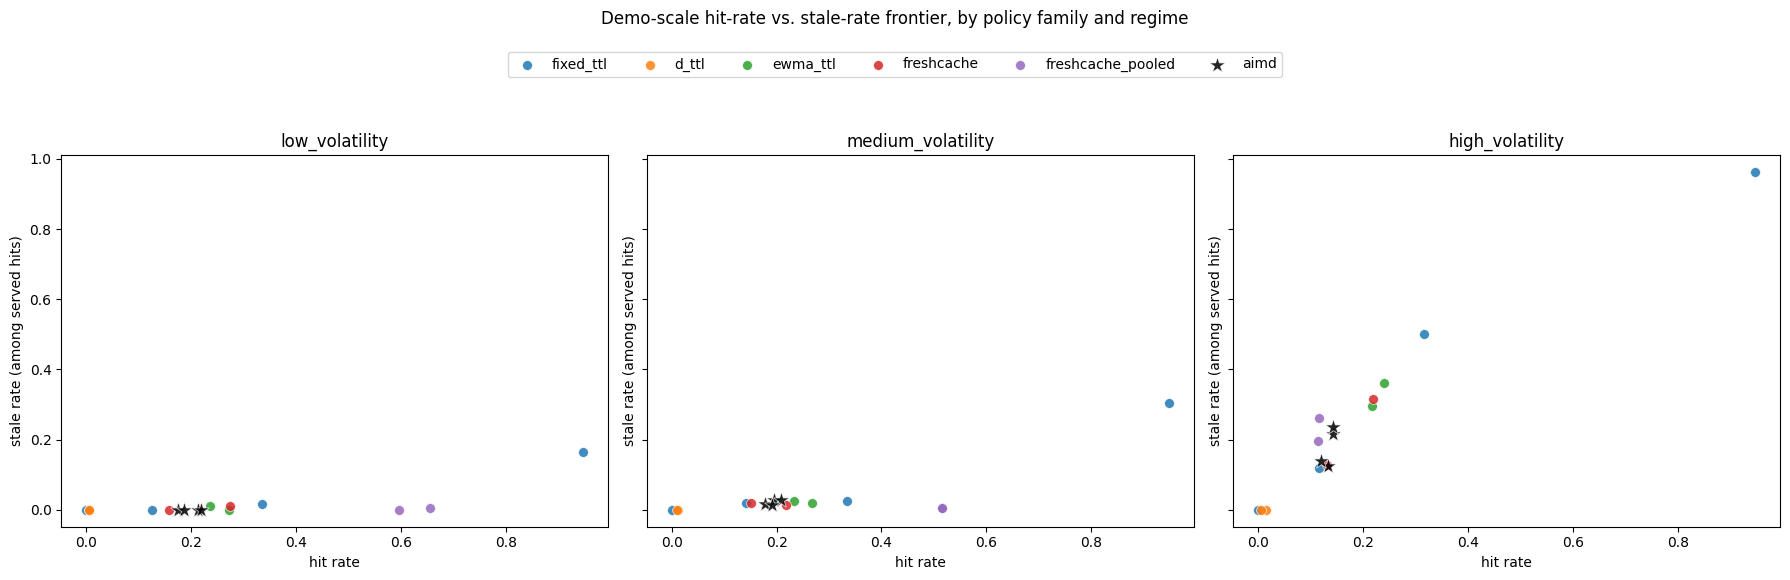

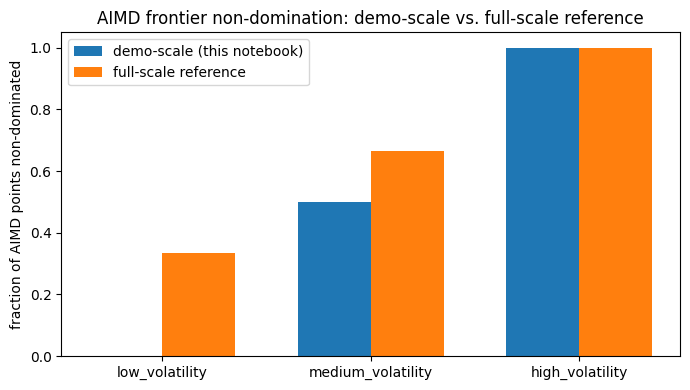

Low-repeat mini-check: {'freshcache_lambda_final': 0.1, 'freshcache_lambda_prior': 0.1, 'freshcache_calibrated': False, 'aimd_window_final': 2.0, 'aimd_window_init': 1.0, 'aimd_window_moved': True}
Boundary sanity checks: {'aimd_window_grows_on_valid_hits': True, 'aimd_window_collapses_on_stale_hit': True, 'aimd_window_recovers_after_collapse': True, 'dttl_stuck_at_floor_from_low_init': True, 'dttl_well_behaved_from_high_init': True, 'ewma_recovers_from_low_init_where_dttl_gets_stuck': True}


In [12]:
print(f"{'regime':<18}{'policy_family':<18}{'n_pts':<8}{'n_dominated':<14}{'frac_non_dominated':<20}")
for regime, d in dominance_summary.items():
    print(f"{regime:<18}{'aimd':<18}{d['n_aimd_points']:<8}{d['n_dominated']:<14}{str(round(d['fraction_non_dominated'], 3)) if d['fraction_non_dominated'] is not None else 'None':<20}")

print()
print("Demo-scale verdict:", verdict, "| criteria: a(frontier)=", criterion_a_pass, " b(low-repeat)=", criterion_b_pass)
print("Full-scale reference verdict (mini_demo_data.json):", data["verdict"], "| criteria:", data["verdict_criteria"])

fig, axes = plt.subplots(1, len(regimes), figsize=(6 * len(regimes), 5), sharey=True)
if len(regimes) == 1:
    axes = [axes]
colors = {
    "fixed_ttl": "tab:blue", "d_ttl": "tab:orange", "ewma_ttl": "tab:green",
    "freshcache": "tab:red", "freshcache_pooled": "tab:purple", "aimd": "black",
}
for ax, regime in zip(axes, regimes):
    rs = [r for r in results if r["regime"] == regime]
    for family in colors:
        fam_pts = [r for r in rs if r["policy_family"] == family]
        if not fam_pts:
            continue
        xs = [r["hit_rate"] for r in fam_pts]
        ys = [r["stale_rate"] for r in fam_pts]
        marker = "*" if family == "aimd" else "o"
        size = 140 if family == "aimd" else 50
        ax.scatter(xs, ys, label=family, color=colors[family], marker=marker, s=size, alpha=0.85, edgecolors="white", linewidths=0.5)
    ax.set_title(regime)
    ax.set_xlabel("hit rate")
    ax.set_ylabel("stale rate (among served hits)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(colors), bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Demo-scale hit-rate vs. stale-rate frontier, by policy family and regime", y=1.15)
plt.tight_layout()
plt.show()

# side-by-side dominance comparison: this notebook's demo-scale run vs. the full-scale reference
fig2, ax2 = plt.subplots(figsize=(7, 4))
regime_labels = list(dominance_summary.keys())
demo_vals = [dominance_summary[r]["fraction_non_dominated"] or 0.0 for r in regime_labels]
ref_vals = [data["dominance_summary"][r]["fraction_non_dominated"] or 0.0 for r in regime_labels]
x = np.arange(len(regime_labels))
width = 0.35
ax2.bar(x - width / 2, demo_vals, width, label="demo-scale (this notebook)")
ax2.bar(x + width / 2, ref_vals, width, label="full-scale reference")
ax2.set_xticks(x)
ax2.set_xticklabels(regime_labels)
ax2.set_ylabel("fraction of AIMD points non-dominated")
ax2.set_title("AIMD frontier non-domination: demo-scale vs. full-scale reference")
ax2.legend()
plt.tight_layout()
plt.show()

print("\
Low-repeat mini-check:", low_repeat_check)
print("Boundary sanity checks:", {k: v for k, v in boundary_checks.items() if isinstance(v, bool)})